In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Đọc dữ liệu
data = pd.read_csv('diabetes_data_upload.csv')

# Kiểm tra dữ liệu
print(data.head())

   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No             Yes   
4             No             Yes     Yes          Yes             Yes   

  partial paresis muscle stiffness Alopecia Obesity     class  
0              No              Yes      

In [11]:
# Chuyển đổi các giá trị phân loại thành số (nếu cần thiết)
data['class'] = data['class'].map({'Positive': 1, 'Negative': 0})
data = pd.get_dummies(data, drop_first=True)  # Mã hóa các biến phân loại

# Xử lý các giá trị thiếu (nếu có)
data.dropna(inplace=True)


In [12]:
# Tách các biến đầu vào (X) và biến mục tiêu (y)
X = data.drop('class', axis=1)
y = data['class']


In [13]:
# Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [14]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=10)  # Chọn 10 đặc trưng quan trọng nhất
rfe.fit(X_train, y_train)

RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=10)

In [16]:
# Danh sách các đặc trưng quan trọng
important_features = X.columns[rfe.support_]
print("Các đặc trưng quan trọng được chọn:")
print(important_features)


Các đặc trưng quan trọng được chọn:
Index(['Age', 'Gender_Male', 'Polyuria_Yes', 'Polydipsia_Yes',
       'sudden weight loss_Yes', 'Genital thrush_Yes', 'visual blurring_Yes',
       'Itching_Yes', 'Irritability_Yes', 'partial paresis_Yes'],
      dtype='object')


In [17]:
# Lấy dữ liệu chỉ gồm các đặc trưng quan trọng
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

In [18]:
# Tạo mô hình hồi quy logistic
model = LogisticRegression(max_iter=1000)


In [19]:
# Huấn luyện mô hình
model.fit(X_train_rfe, y_train)

# Dự đoán kết quả trên tập kiểm tra
y_pred = model.predict(X_test_rfe)

In [20]:
# Đánh giá mô hình
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[49  5]
 [ 3 99]]


In [26]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        54
           1       0.95      0.97      0.96       102

    accuracy                           0.95       156
   macro avg       0.95      0.94      0.94       156
weighted avg       0.95      0.95      0.95       156

Accuracy: 0.95


Accuracy: 0.95


In [23]:
# Phân tích hệ số hồi quy
coefficients = pd.DataFrame({
    'Feature': important_features,
    'Coefficient': model.coef_[0]
})
print("\nHệ số hồi quy sau khi chọn đặc trưng:")
print(coefficients)


Hệ số hồi quy sau khi chọn đặc trưng:
                  Feature  Coefficient
0                     Age    -0.447345
1             Gender_Male    -1.442827
2            Polyuria_Yes     1.472393
3          Polydipsia_Yes     1.753784
4  sudden weight loss_Yes     0.540018
5      Genital thrush_Yes     0.706972
6     visual blurring_Yes     0.495718
7             Itching_Yes    -1.028310
8        Irritability_Yes     0.735393
9     partial paresis_Yes     0.582433


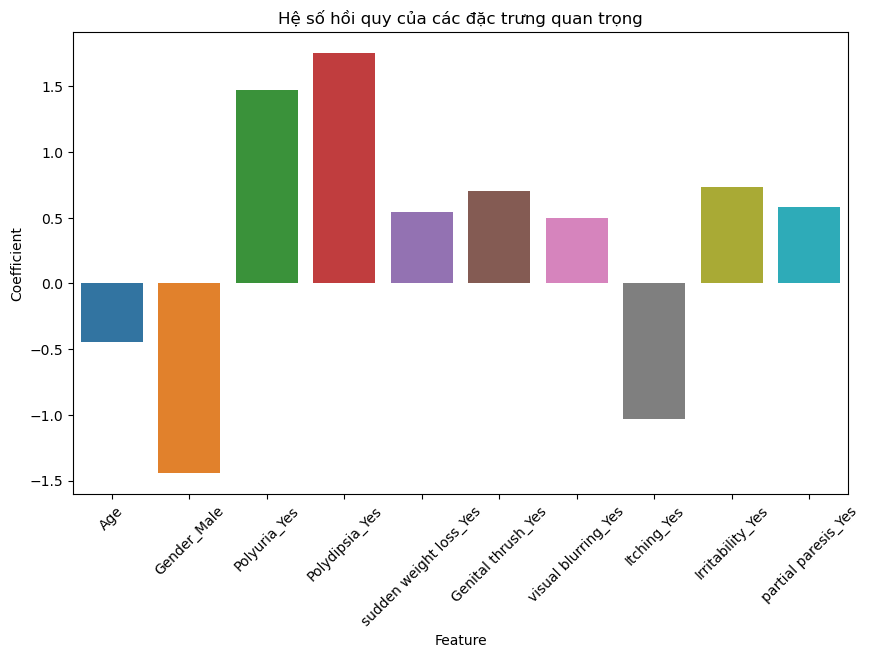

In [24]:
# Trực quan hóa các hệ số hồi quy
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Coefficient', data=coefficients)
plt.xticks(rotation=45)
plt.title("Hệ số hồi quy của các đặc trưng quan trọng")
plt.show()